# Metadata Yönetimi İçin DB Gerekli mi? 

## Nessie vs Hive

> Nessie için gerekli değildir ama yönetim kolaylığı için eklenebilir. Ancak Hive için gereklidir. 

> garbage collection için bir db bağlantısı gereklidir.

Nessie Quarkus Server, Postgres ve MariaDB veya bunlarla uyumlu herhangi bir veri tabanı için yerleşik destekle birlikte gelir. 

- postgresql
- mariadb
- mysql
- h2
- mongo
- dynamodb
- cassandra

source: https://github.com/projectnessie/nessie/blob/main/servers/quarkus-server/src/main/resources/application.properties



## Nessie - Iceberg sanpshot yönetimi

- Currently the GC algorithm only works for Iceberg tables. A supported JDBC database is recommended as the storage for the live-content-sets.
-  Iceberg table snapshots are not automatically deleted.

Örnekler: https://github.com/apache/iceberg/issues/1597

### Hive Metastore:

Temel Amaç: Hive Metastore, Apache Hive ekosisteminin bir parçasıdır ve veri kaynaklarındaki tablo metadata bilgilerini saklar. Hadoop ekosisteminde kullanılan ve büyük veri analitiği için yaygın olarak tercih edilen bir bileşendir. Temel işlevi, veritabanı, tablo, sütun bilgileri gibi metadata'yı yönetmektir.

Veri Yapıları: Hive Metastore, verilerin düzenli bir şekilde saklanması için veri yapıları sağlar. Örneğin, veritabanı ve tablo düzeyinde metadata yönetimi yapar.

Depolama: Hive Metastore, genellikle ilişkisel bir veritabanı (MySQL, PostgreSQL vb.) kullanarak metadata'yı depolar. Bu, Hive'ın kullanıcıların verilerine hızlı erişim sağlaması için önemli bir rol oynar.

Kullanım Alanı: Büyük veri işleme ortamlarında (Hadoop, Spark gibi) ve özellikle ETL süreçlerinde yaygın olarak kullanılır.

### Nessie:

Temel Amaç: Nessie, bir veri sürümleme aracı olarak çalışır. Nessie, veri lake'lerinde (örneğin, Delta Lake veya Iceberg gibi) veri üzerinde versiyon kontrolü sağlar. Yani, verilerin farklı sürümlerinin saklanmasını ve yönetilmesini sağlar.

Veri Yapıları: Nessie, veriler üzerinde sürüm yönetimini sağlar. Delta Lake, Iceberg gibi projelerle birlikte çalışarak, veri üzerinde yapılan değişiklikleri (insert, update, delete) izler ve versiyonlar arasında geçiş yapmayı mümkün kılar.

Depolama: Nessie, verinin kendisinden ziyade metadata ve versiyon bilgilerini saklar. Verilerin geriye dönük sürümlerini saklayarak veri ambarı ve lake'lerdeki veriye yönelik işlemleri yönetir.

Kullanım Alanı: Nessie, veri lake'leri ile entegre çalışarak büyük veri yönetimi ve analitiği için daha esnek bir yapıyı mümkün kılar. Özellikle veri versiyonlaması, veri geçmişi ve daha güvenli veri erişimi gibi özellikleriyle öne çıkar.



| **Özellik**                | **Hive Metastore**                               | **Nessie**                                          |
|----------------------------|--------------------------------------------------|-----------------------------------------------------|
| **Temel Amaç**              | Veri metadata yönetimi (tablo, sütun, vb.)      | Veri sürümleme ve versiyon kontrolü                |
| **Veri Yapıları**           | Veritabanı ve tablo düzeyinde metadata yönetimi | Veri sürümleri ve değişikliklerin yönetimi         |
| **Depolama**                | İlişkisel veritabanı (MySQL, PostgreSQL, vb.)   | Versiyon bilgisi ve metadata; veri lake'lerinde çalışır |
| **Kullanım Alanı**           | Büyük veri işleme (Hadoop, Spark, vb.)          | Veri lake'leri (Delta Lake, Iceberg, vb.) ile entegrasyon |
| **Veri Sürümleme**          | Desteklemez                                        | Veri sürümlerini yönetir ve geçmiş verilere erişim sağlar |
| **Entegrasyon**             | Hadoop ekosistemi ve Hive                      | Delta Lake, Iceberg, ve diğer modern veri lake'leriyle çalışır |
| **Öne Çıkan Özellikler**    | Veri tablosu metadata yönetimi ve optimizasyon  | Esnek veri sürümleme, veri güvenliği ve geçmiş veriye erişim |



![hive](https://tibco-computedb.readthedocs.io/en/enterprise_docv1.2.0/Images/externalhivemetastore/local_metastore.png)

Hem Kullanılabilirlik hem de performans açısından belirgin eksikliklerden muzdariptir. Özellikle Hive Metastore:

- Kurulumu ve bakımı zordur.
- İlişkisel veritabanı bağımlılığından kaynaklanan ölçeklenebilirlik kısıtlamalarına maruz kalmaktadır.

# Best Practices
- https://docs.dremio.com/current/help-support/best-practices/semantic_layer

## Madalyon Mimarisi Nedir?

![image.png](https://www.databricks.com/sites/default/files/inline-images/building-data-pipelines-with-delta-lake-120823.png?v=1702318922)



### 1. Bronze Katman (Ham Veri Katmanı)

**Özellikleri:**

Bu katmanda, çeşitli kaynaklardan toplanan ham veriler yer alır. Veriler henüz işlenmemiş, temizlenmemiş ve düzenlenmemiştir.

**Amaç:**

Verilerin ilk toplama aşaması olarak, veri kaybı olmadan olabildiğince geniş kapsamlı veri saklamak.

**Örnek:**

- RT3A raw data


### 2. Silver Katman (Temizleme ve Dönüştürme Katmanı)

**Özellikleri:**

Bronze katmandan alınan veriler burada temizlenir, standartlaştırılır ve gerekirse zenginleştirilir. Hatalı, eksik veya tutarsız veriler bu aşamada düzeltilir.

**Amaç:**

Verinin kalitesini artırarak, analiz ve iş süreçlerine uygun hale getirmek. Bu katmanda veri doğrulama, veri bütünlüğü sağlama ve dönüşüm işlemleri uygulanır.

**Örnek:**

- BATAP(INTERLINE Projesinde)
- IATCI
- NDC gibi verilerin raw datadan alınarak temizlenmiş halleri

### 3. Gold Katman (İş Değeri Üreten Katman)

**Özellikleri:**

Silver katmandan gelen veriler, iş ihtiyaçlarına yönelik özetlemeler, modellemeler ve analizler ile işlenir. Bu katman, son kullanıcıların doğrudan raporlama, görselleştirme veya makine öğrenimi gibi uygulamalarda 
kullanabileceği veri setlerini sunar.

**Amaç:**

İş kararlarını destekleyecek, yüksek kaliteli ve hazır veri sağlamak.

**Örnek:**

- PNR SYNC RATE View (INTERLINE Projesinde)
- IATCI Raporları(oracle'a yazılan taraf)


## Uygulama Katmanı (Dremio)

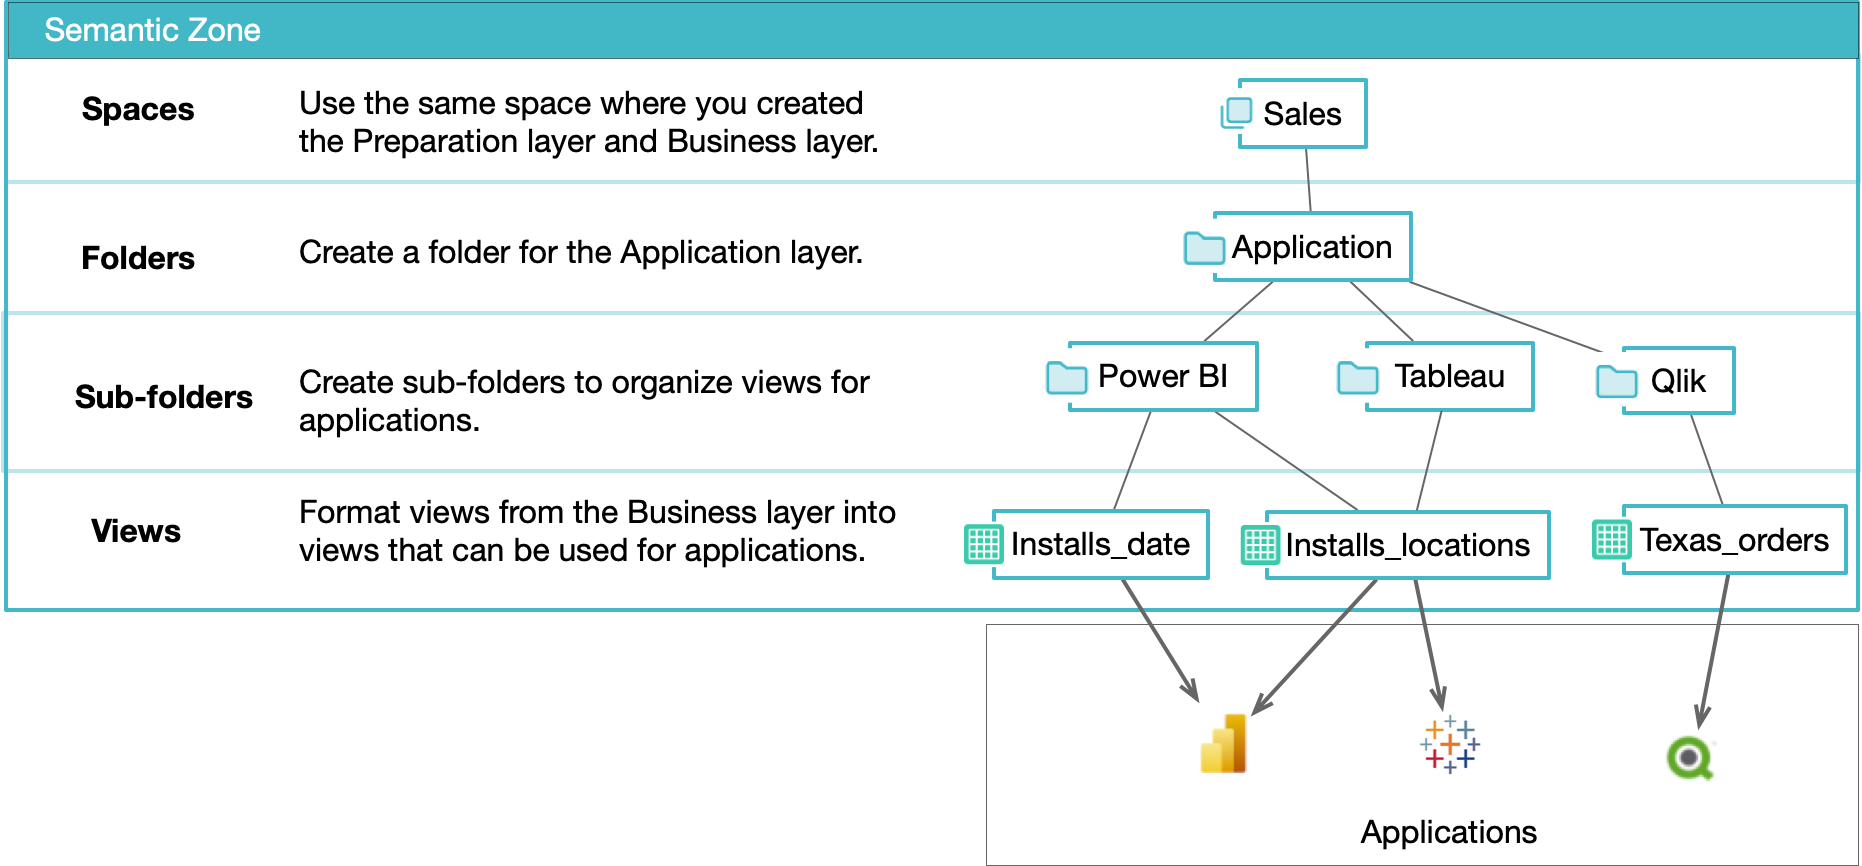

----

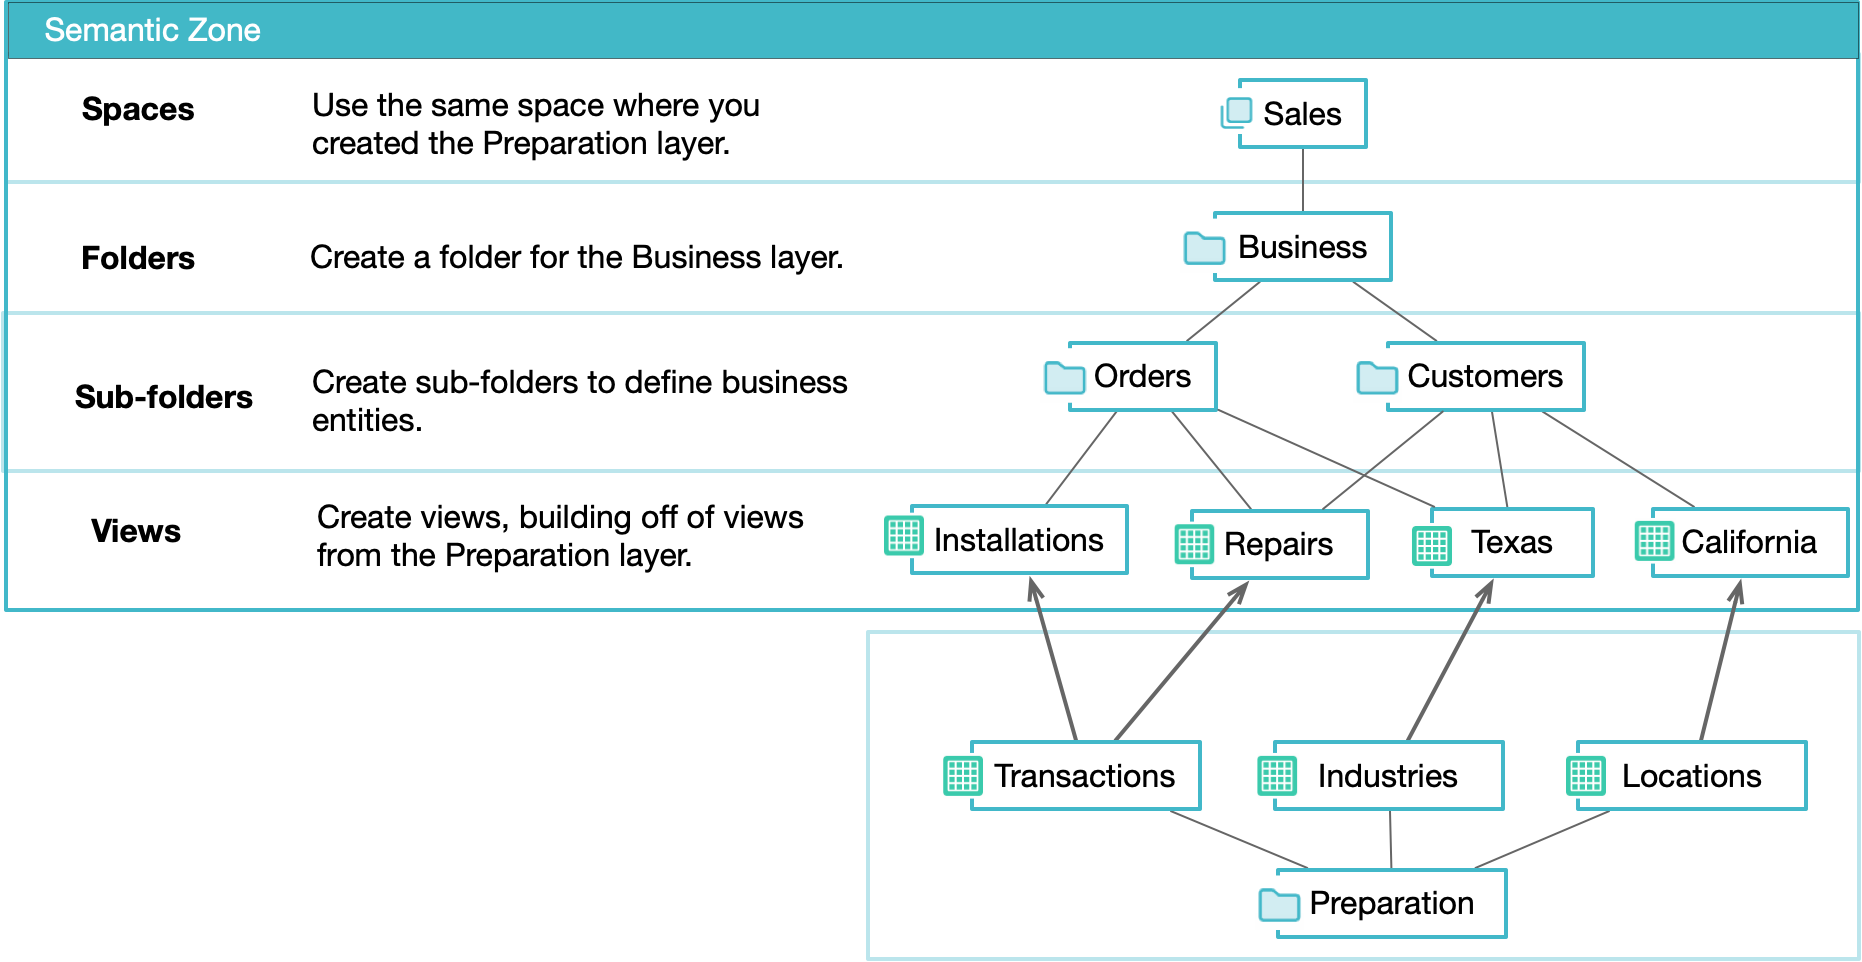

## Yetki Tanımları

| DEV | PROD |
|-----|------|
| 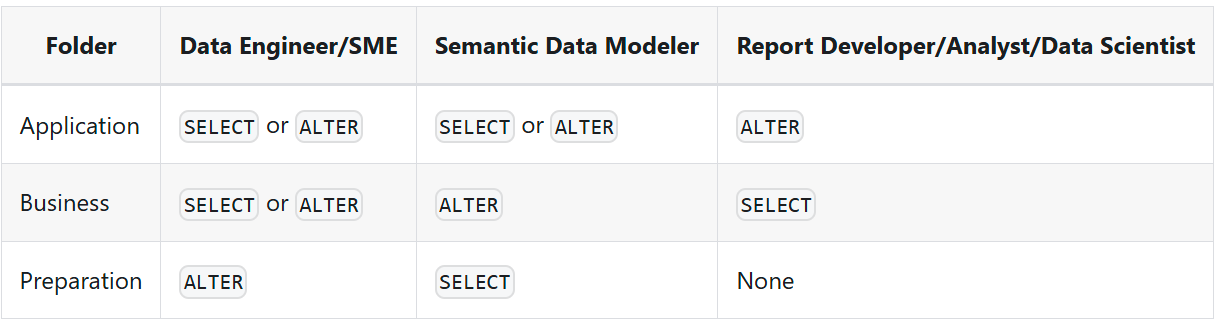 | 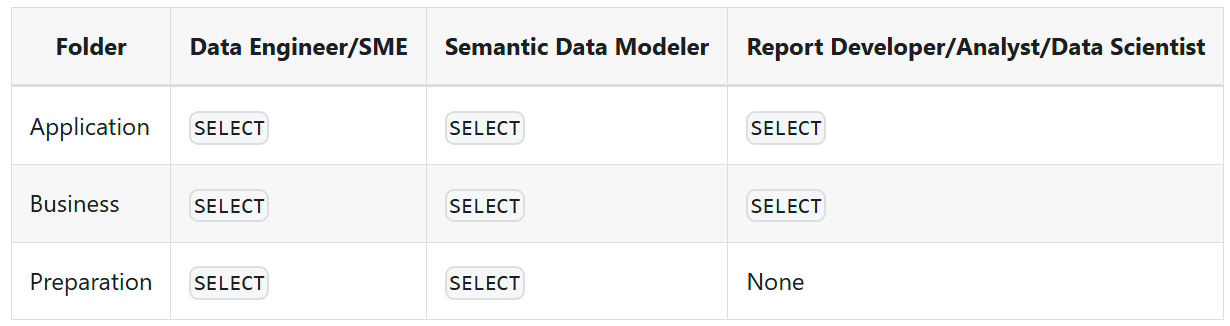 |

# Nifi Nessie Desteği ?

nifi native olarak desteklemiyor ama rest catalog yapısıyla belirli oranda haberleşebilir.(InvokeHTTP) 
- Olmadı

POST http://nessie:19120/api/v1/commits

In [ ]:
{
  "message": "NiFi Commit",
  "operations": [
    {
      "type": "PUT",
      "key": {
        "elements": ["my_table"]
      },
      "contents": {
        "type": "ICEBERG_TABLE",
        "metadataLocation": "s3://my-bucket/iceberg-tables/my_table/metadata/00001-<uuid>.metadata.json"
      }
    }
  ]
}

# Dremio-Nessie-S3 Parquet Okuma

Dremio üzerinden s3 e sorgu atılıyor ancak nessie ile haberleşerek direkt paruqet file okunamıyor